In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/fruits_20_clean.zip', 'r') as z:
    z.extractall('/content/fruits')

Mounted at /content/drive


Number of classes: 20
Classes: ['Apple Granny Smith 1', 'Apple Red 1', 'Avocado 1', 'Banana 1', 'Blueberry 1', 'Cherry 1', 'Cocos 1', 'Grape Blue 1', 'Kiwi 1', 'Lemon 1', 'Mango 1', 'Orange 1', 'Papaya 1', 'Peach 1', 'Pear 1', 'Pineapple 1', 'Pomegranate 1', 'Raspberry 1', 'Strawberry 1', 'Watermelon 1']


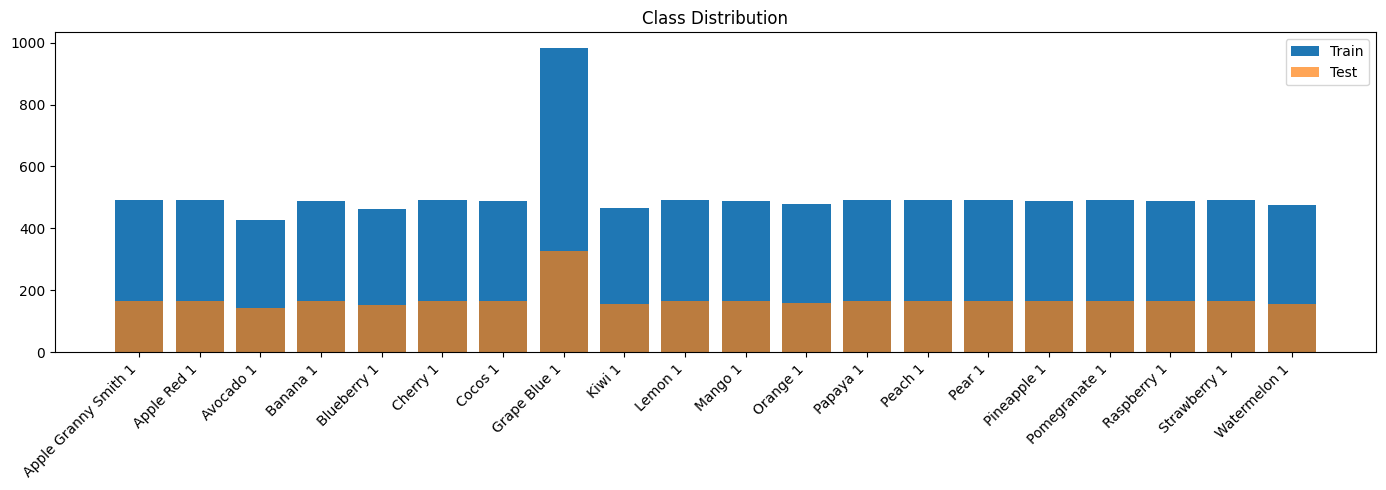

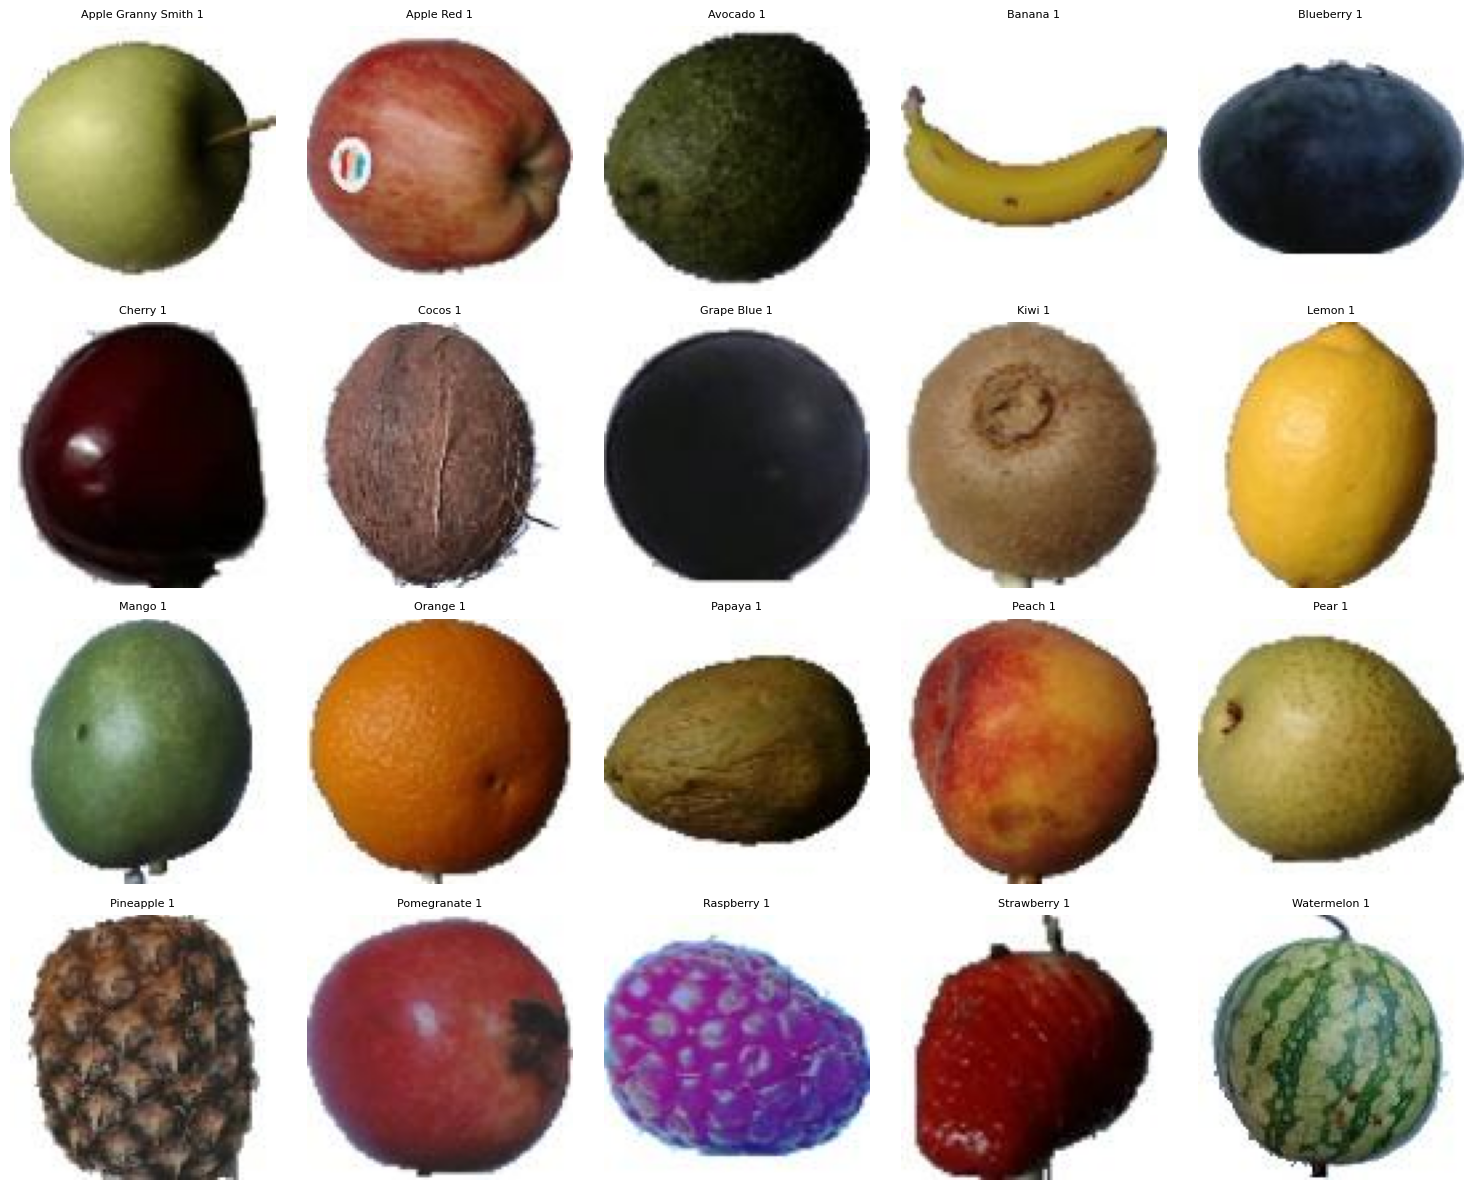

In [4]:
import os, matplotlib.pyplot as plt, numpy as np
from PIL import Image
from collections import Counter

train_dir = '/content/fruits/Training'
test_dir  = '/content/fruits/Test'

classes = sorted(os.listdir(train_dir))
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

train_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(test_dir,  c))) for c in classes}

plt.figure(figsize=(14,5))
plt.bar(train_counts.keys(), train_counts.values(), label='Train')
plt.bar(test_counts.keys(),  test_counts.values(),  label='Test', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(); plt.title("Class Distribution"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for ax, cls in zip(axes.flatten(), classes):
    img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
    ax.imshow(Image.open(img_path))
    ax.set_title(cls, fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
test_data  = test_gen.flow_from_directory(test_dir,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

NUM_CLASSES = len(classes)  # 20

Found 10171 images belonging to 20 classes.
Found 3404 images belonging to 20 classes.


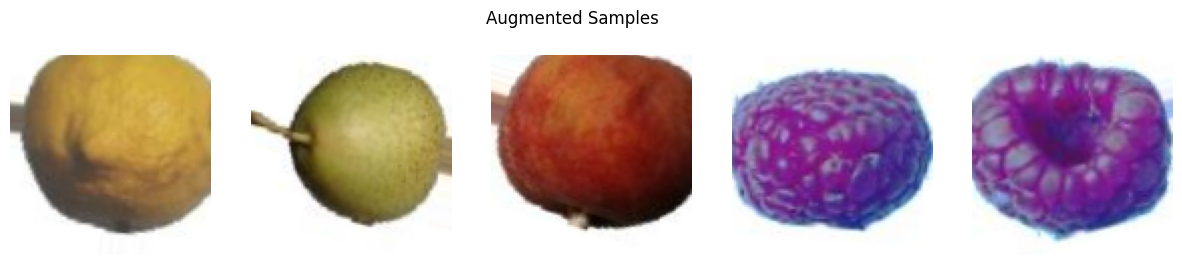

In [6]:
sample_batch = next(train_data)
fig, axes = plt.subplots(1, 5, figsize=(15,3))
for ax, img in zip(axes, sample_batch[0][:5]):
    ax.imshow(img); ax.axis('off')
plt.suptitle("Augmented Samples"); plt.show()

In [7]:
from tensorflow.keras import layers, models

def build_baseline():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')  # output layer
    ])
    return model

baseline = build_baseline()
baseline.summary()

baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_baseline = baseline.fit(train_data, epochs=20, validation_data=test_data)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,412,756 (13.02 MB)

 Trainable params: 3,412,756 (13.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 47s 128ms/step - accuracy: 0.8286 - loss: 0.5168 - val_accuracy: 0.9562 - val_loss: 0.1233
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9678 - loss: 0.0955 - val_accuracy: 0.9865 - val_loss: 0.0318
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9766 - loss: 0.0734 - val_accuracy: 0.9915 - val_loss: 0.0176
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.9746 - loss: 0.0786 - val_accuracy: 0.9974 - val_loss: 0.0078
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9944 - val_loss: 0.0169
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9736 - loss: 0.0826 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.9969 - loss: 0.0104 - val_accuracy: 0.9818 - val_loss: 0.0327
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9763 - loss: 0

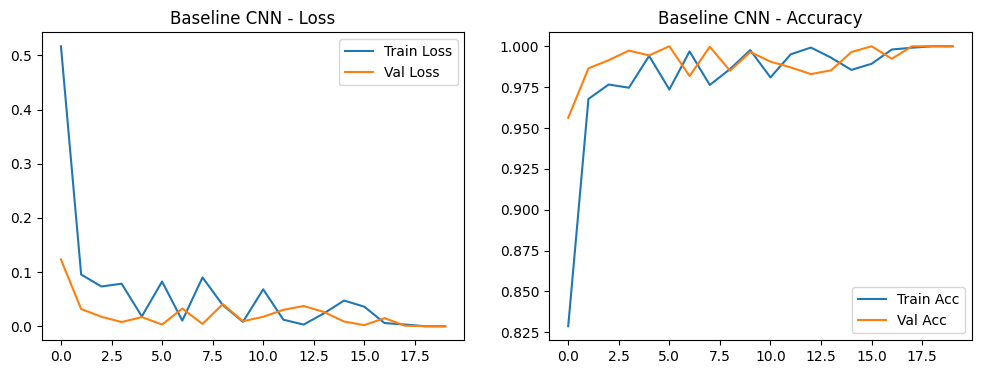

In [8]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy'); plt.legend()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step
                      precision    recall  f1-score   support

Apple Granny Smith 1       1.00      1.00      1.00       164
         Apple Red 1       1.00      1.00      1.00       164
           Avocado 1       1.00      1.00      1.00       143
            Banana 1       1.00      1.00      1.00       166
         Blueberry 1       1.00      1.00      1.00       154
            Cherry 1       1.00      1.00      1.00       164
             Cocos 1       1.00      1.00      1.00       166
        Grape Blue 1       1.00      1.00      1.00       328
              Kiwi 1       1.00      1.00      1.00       156
             Lemon 1       1.00      1.00      1.00       164
             Mango 1       1.00      1.00      1.00       166
            Orange 1       1.00      1.00      1.00       160
            Papaya 1       1.00      1.00      1.00       164
             Peach 1       1.00      1.00      1.00       164
              Pear 1       

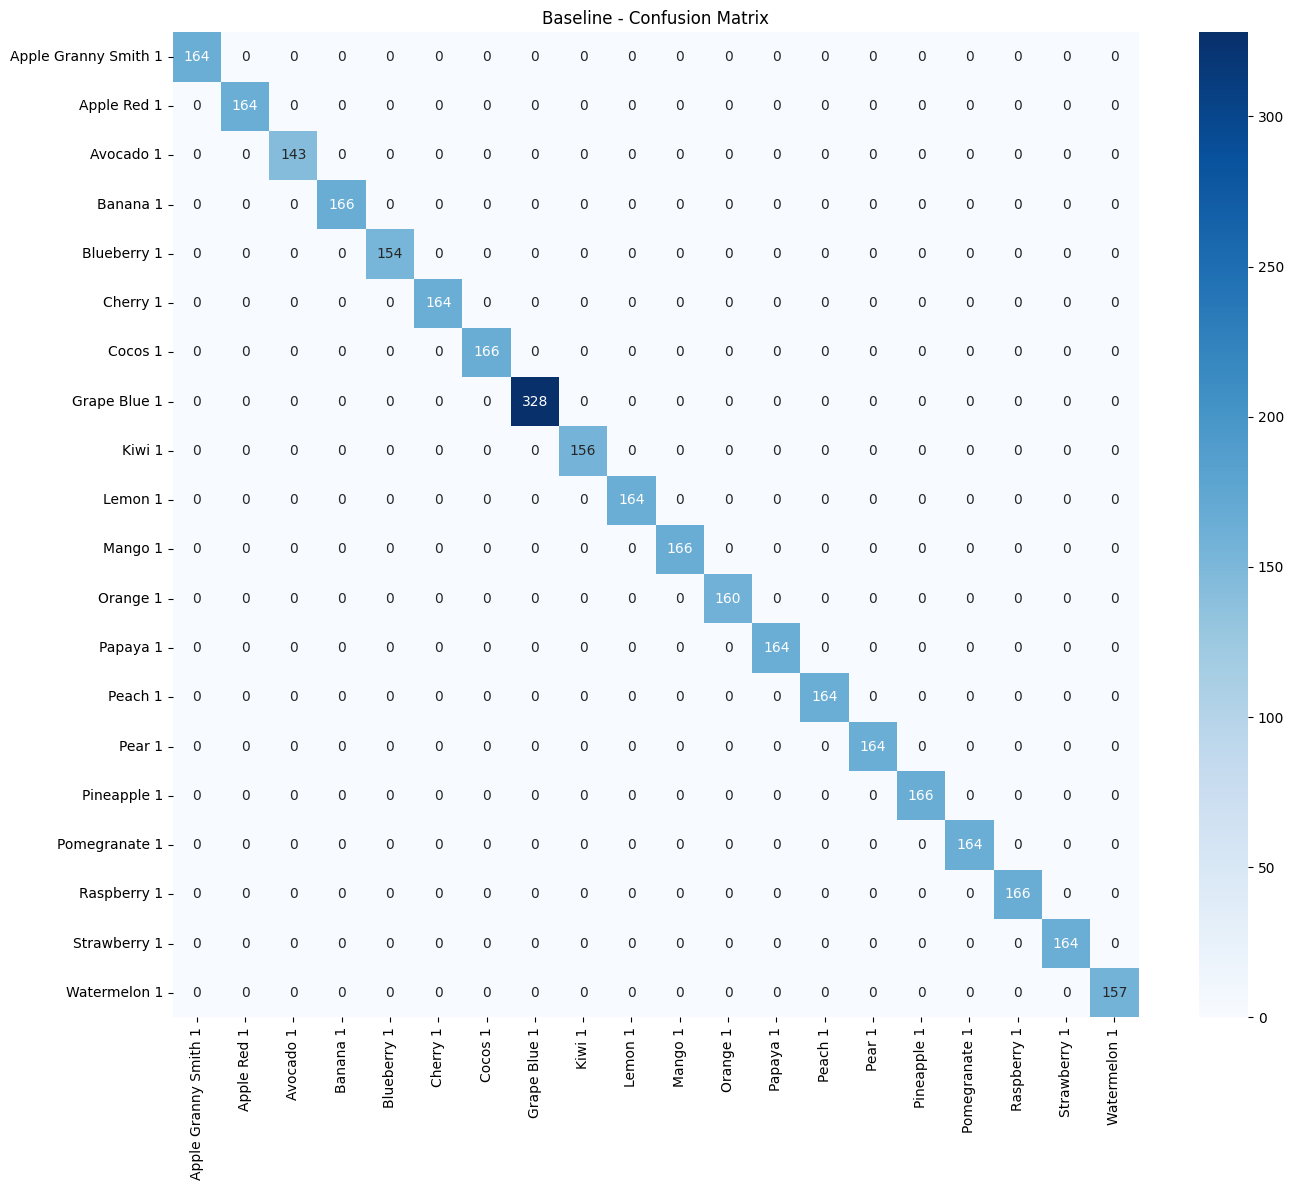

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_data.reset()
y_pred = np.argmax(baseline.predict(test_data), axis=1)
y_true = test_data.classes

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, xticklabels=classes, yticklabels=classes, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline - Confusion Matrix"); plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 6,031,796 (23.01 MB)

 Trainable params: 6,029,812 (23.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 72s 172ms/step - accuracy: 0.6596 - loss: 1.1054 - val_accuracy: 0.2130 - val_loss: 6.9896
Epoch 2/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - accuracy: 0.8999 - loss: 0.3209 - val_accuracy: 0.8361 - val_loss: 0.5965
Epoch 3/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.9382 - loss: 0.2037 - val_accuracy: 0.7638 - val_loss: 1.3200
Epoch 4/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9424 - loss: 0.1948 - val_accuracy: 0.7873 - val_loss: 1.8641
Epoch 5/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.9621 - loss: 0.1286 - val_accuracy: 0.9709 - val_loss: 0.0821
Epoch 6/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9613 - loss: 0.1364 - val_accuracy: 0.9850 - val_loss: 0.0379
Epoch 7/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.9673 - loss: 0.1015 - val_accuracy: 0.9650 - val_loss: 0.1314
Epoch 8/30
318/318 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9751 - loss: 0

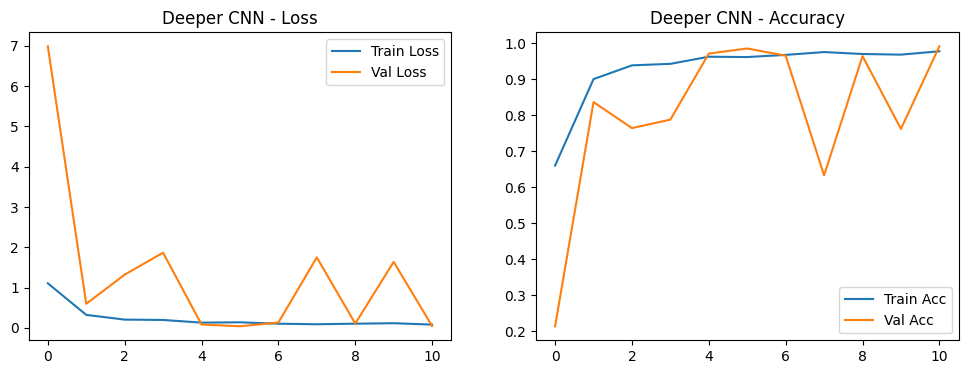

In [10]:
from tensorflow.keras.layers import BatchNormalization, Dropout

def build_deeper():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(100,100,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),

        Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        layers.Dense(256, activation='relu'),
        Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

deeper = build_deeper()
deeper.summary()
deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_deeper = deeper.fit(train_data, epochs=30, validation_data=test_data, callbacks=[es])
plot_history(history_deeper, "Deeper CNN")

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 56s 145ms/step - accuracy: 0.4798 - loss: 1.7806 - val_accuracy: 0.1980 - val_loss: 5.1338
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.7655 - loss: 0.6652 - val_accuracy: 0.3931 - val_loss: 3.8992
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.8743 - loss: 0.3553 - val_accuracy: 0.4233 - val_loss: 3.4087
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.9086 - loss: 0.2667 - val_accuracy: 0.5120 - val_loss: 3.5140
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.9432 - loss: 0.1745 - val_accuracy: 0.6178 - val_loss: 2.7709


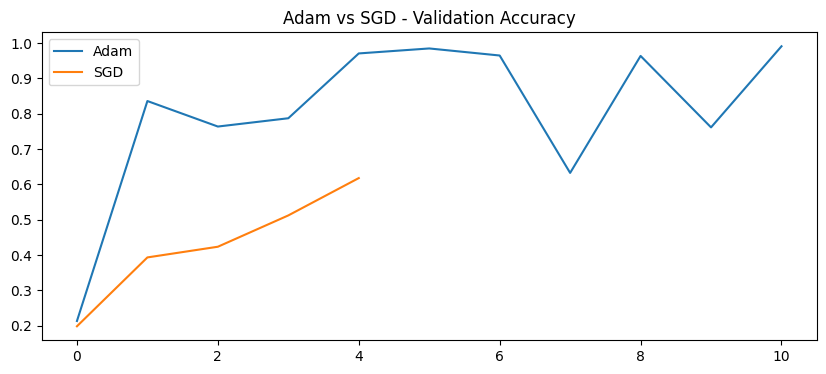

In [11]:
deeper_sgd = build_deeper()
deeper_sgd.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history_sgd = deeper_sgd.fit(train_data, epochs=20, validation_data=test_data, callbacks=[es])

plt.figure(figsize=(10,4))
plt.plot(history_deeper.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.title("Adam vs SGD - Validation Accuracy"); plt.legend(); plt.show()

In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

base_model = MobileNetV2(input_shape=(100,100,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)
tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_tl = tl_model.fit(train_data, epochs=10, validation_data=test_data, callbacks=[es])

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # very low LR!
                 loss='categorical_crossentropy', metrics=['accuracy'])
history_tl_ft = tl_model.fit(train_data, epochs=10, validation_data=test_data, callbacks=[es])

/tmp/ipykernel_2638/2831795582.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(100,100,3), include_top=False, weights='imagenet')


Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 56s 143ms/step - accuracy: 0.9422 - loss: 0.1955 - val_accuracy: 0.9727 - val_loss: 0.0960
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.9866 - loss: 0.0402 - val_accuracy: 0.9741 - val_loss: 0.1031
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.9882 - loss: 0.0330 - val_accuracy: 0.9771 - val_loss: 0.0761
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.9935 - loss: 0.0202 - val_accuracy: 0.9909 - val_loss: 0.0391
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.9926 - loss: 0.0221 - val_accuracy: 0.9838 - val_loss: 0.0418
Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 67s 160ms/step - accuracy: 0.9031 - loss: 0.3717 - val_accuracy: 0.9715 - val_loss: 0.1284
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9759 - loss: 0.1023 - val_accuracy: 0.9741 - val_loss: 0.1149
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.9889 - loss: 0